In [4]:
import requests
import json

response = requests.get('https://steamspy.com/api.php', params={"request": "top100in2weeks"})
data = response.json()

print(type(data))
print(len(data))
# ilk oyuna bakalım 
first_game = list(data.keys())[0]
print(data[first_game])
print(json.dumps(data[first_game], indent=4))




<class 'dict'>
100
{'appid': 730, 'name': 'Counter-Strike: Global Offensive', 'developer': 'Valve', 'publisher': 'Valve', 'score_rank': '', 'positive': 7642084, 'negative': 1173003, 'userscore': 0, 'owners': '100,000,000 .. 200,000,000', 'average_forever': 0, 'average_2weeks': 0, 'median_forever': 0, 'median_2weeks': 0, 'price': '0', 'initialprice': '0', 'discount': '0', 'ccu': 1013936}
{
    "appid": 730,
    "name": "Counter-Strike: Global Offensive",
    "developer": "Valve",
    "publisher": "Valve",
    "score_rank": "",
    "positive": 7642084,
    "negative": 1173003,
    "userscore": 0,
    "owners": "100,000,000 .. 200,000,000",
    "average_forever": 0,
    "average_2weeks": 0,
    "median_forever": 0,
    "median_2weeks": 0,
    "price": "0",
    "initialprice": "0",
    "discount": "0",
    "ccu": 1013936
}


In [5]:
import pandas as pd
df = pd.DataFrame.from_dict(data, orient='index')
print(df.head(5))


           appid                              name         developer  \
730          730  Counter-Strike: Global Offensive             Valve   
1172470  1172470                      Apex Legends           Respawn   
578080    578080               PUBG: BATTLEGROUNDS  PUBG Corporation   
1623730  1623730                          Palworld        Pocketpair   
440          440                   Team Fortress 2             Valve   

               publisher score_rank  positive  negative  userscore  \
730                Valve              7642084   1173003          0   
1172470  Electronic Arts               668053    326926          0   
578080     KRAFTON, Inc.              1520457   1037487          0   
1623730       Pocketpair               358266     22443          0   
440                Valve              1044264    117208          0   

                             owners  average_forever  average_2weeks  \
730      100,000,000 .. 200,000,000                0               0   
11

In [6]:
df = df.drop(columns=['average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'userscore', 'score_rank'])
print(df.columns)


Index(['appid', 'name', 'developer', 'publisher', 'positive', 'negative',
       'owners', 'price', 'initialprice', 'discount', 'ccu'],
      dtype='str')


In [7]:
df['price'] = df['price'].astype(int) / 100
df['initialprice'] = df['initialprice'].astype(int) / 100
print(df[['name', 'price', 'initialprice', 'discount']].head(5))

print((df['price'] == 0).sum(), "ücretsiz oyun")
print((df['price'] > 0).sum(), "ücretli oyun")

                                     name  price  initialprice discount
730      Counter-Strike: Global Offensive   0.00          0.00        0
1172470                      Apex Legends   0.00          0.00        0
578080                PUBG: BATTLEGROUNDS   0.00          0.00        0
1623730                          Palworld  20.99         29.99       30
440                       Team Fortress 2   0.00          0.00        0
33 ücretsiz oyun
67 ücretli oyun


In [8]:
def owners_to_midpoint(owners_str):
    parts = owners_str.replace(",", "").split(" .. ")
    low = int(parts[0])
    high = int(parts[1])
    midpoint = (low + high) / 2
    return midpoint


df['owners_mid'] = df['owners'].apply(owners_to_midpoint)
print(df[['name', 'owners', 'owners_mid']].head(5))

                                     name                      owners  \
730      Counter-Strike: Global Offensive  100,000,000 .. 200,000,000   
1172470                      Apex Legends  100,000,000 .. 200,000,000   
578080                PUBG: BATTLEGROUNDS  100,000,000 .. 200,000,000   
1623730                          Palworld   50,000,000 .. 100,000,000   
440                       Team Fortress 2   50,000,000 .. 100,000,000   

          owners_mid  
730      150000000.0  
1172470  150000000.0  
578080   150000000.0  
1623730   75000000.0  
440       75000000.0  


In [9]:
import time

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

genres = {}

for i, appid in enumerate(df['appid']):
    try:
        resp = requests.get('https://steamspy.com/api.php', params={"request": "appdetails", "appid": appid}, headers=headers)
        detail = resp.json()
        genres[appid] = detail.get('genre', None)
    except Exception as e:
        genres[appid] = None
        print(f"Hata: {appid} - {e}")
    
    if i % 10 == 0:
        print(f"{i}/100 tamamlandı...")
    
    time.sleep(1)

print("Bitti!")

0/100 tamamlandı...
10/100 tamamlandı...
20/100 tamamlandı...
30/100 tamamlandı...
40/100 tamamlandı...
50/100 tamamlandı...
60/100 tamamlandı...
70/100 tamamlandı...
80/100 tamamlandı...
90/100 tamamlandı...
Bitti!


In [10]:
df['genre'] = df['appid'].map(genres)
print(df[['name', 'genre']].head(10))

                                     name  \
730      Counter-Strike: Global Offensive   
1172470                      Apex Legends   
578080                PUBG: BATTLEGROUNDS   
1623730                          Palworld   
440                       Team Fortress 2   
1938090   Call of Duty: Modern Warfare II   
1063730               New World: Aeternum   
2358720                Black Myth: Wukong   
271590          Grand Theft Auto V Legacy   
550                         Left 4 Dead 2   

                                                     genre  
730                                   Action, Free To Play  
1172470                    Action, Adventure, Free To Play  
578080   Action, Adventure, Massively Multiplayer, Free...  
1623730                      Action, Adventure, Indie, RPG  
440                                   Action, Free To Play  
1938090                                             Action  
1063730      Action, Adventure, Massively Multiplayer, RPG  
2358720         

In [11]:
import sqlite3
conn = sqlite3.connect('steam_data.db')
df.to_sql('STEAM_GAMES', conn, if_exists='replace', index=False)

print("Veriler SQLite veritabanına kaydedildi.")

check = pd.read_sql("SELECT COUNT(*) FROM STEAM_GAMES", conn)
print(check)
print(f"Toplam kayıt sayısı: {check.iloc[0, 0]}")


Veriler SQLite veritabanına kaydedildi.
   COUNT(*)
0       100
Toplam kayıt sayısı: 100


In [12]:
query = """
SELECT name, positive , negative, 
ROUND(positive * 1.0 / (positive + negative), 3) AS review_ratio
FROM STEAM_GAMES
WHERE (positive + negative) > 1000
ORDER BY REVIEW_RATIO DESC
LIMIT 10;
"""
top_reviewed= pd.read_sql(query, conn)
print(top_reviewed)


                     name  positive  negative  review_ratio
0                  Portal    175024      2717         0.985
1          Stardew Valley    872384     13811         0.984
2              Schedule I    200803      3238         0.984
3        Wallpaper Engine    876898     17560         0.980
4             Half-Life 2    239721      5906         0.976
5           Left 4 Dead 2    940221     23762         0.975
6                Terraria   1373979     35494         0.975
7  Euro Truck Simulator 2    844480     22924         0.974
8          Counter-Strike    243818      6427         0.974
9          Lethal Company    473422     13738         0.972


In [13]:
query2 = """
SELECT genre , COUNT(*) AS oyun_sayisi, ROUND(AVG(price), 2) AS ortalama_fiyat
FROM STEAM_GAMES
WHERE genre IS NOT NULL
GROUP BY genre
ORDER BY oyun_sayisi DESC
LIMIT 10;
"""
genre_stats = pd.read_sql(query2, conn)
print(genre_stats)


                                               genre  oyun_sayisi  \
0                                             Action           16   
1                      Action, Adventure, Indie, RPG            5   
2                               Action, Free To Play            4   
3                             Action, Adventure, RPG            4   
4                                  Action, Adventure            4   
5                                                RPG            3   
6                                        Action, RPG            3   
7                                           Strategy            2   
8                                 Simulation, Sports            2   
9  Action, Massively Multiplayer, Simulation, Str...            2   

   ortalama_fiyat  
0           19.52  
1           21.19  
2            0.00  
3           46.24  
4           18.75  
5           43.32  
6           29.99  
7           44.99  
8            0.00  
9            0.00  


In [14]:
df['genre_list'] = df['genre'].str.split(', ')
print(df[['name', 'genre', 'genre_list']].head(5))

                                     name  \
730      Counter-Strike: Global Offensive   
1172470                      Apex Legends   
578080                PUBG: BATTLEGROUNDS   
1623730                          Palworld   
440                       Team Fortress 2   

                                                     genre  \
730                                   Action, Free To Play   
1172470                    Action, Adventure, Free To Play   
578080   Action, Adventure, Massively Multiplayer, Free...   
1623730                      Action, Adventure, Indie, RPG   
440                                   Action, Free To Play   

                                                genre_list  
730                                 [Action, Free To Play]  
1172470                  [Action, Adventure, Free To Play]  
578080   [Action, Adventure, Massively Multiplayer, Fre...  
1623730                    [Action, Adventure, Indie, RPG]  
440                                 [Action, Free T

In [15]:
df_exploded = df.explode('genre_list')
print(df_exploded[['name', 'genre', 'genre_list']].head(10))


                                     name  \
730      Counter-Strike: Global Offensive   
730      Counter-Strike: Global Offensive   
1172470                      Apex Legends   
1172470                      Apex Legends   
1172470                      Apex Legends   
578080                PUBG: BATTLEGROUNDS   
578080                PUBG: BATTLEGROUNDS   
578080                PUBG: BATTLEGROUNDS   
578080                PUBG: BATTLEGROUNDS   
1623730                          Palworld   

                                                     genre  \
730                                   Action, Free To Play   
730                                   Action, Free To Play   
1172470                    Action, Adventure, Free To Play   
1172470                    Action, Adventure, Free To Play   
1172470                    Action, Adventure, Free To Play   
578080   Action, Adventure, Massively Multiplayer, Free...   
578080   Action, Adventure, Massively Multiplayer, Free...   
578080  

In [16]:
df_exploded.to_sql('STEAM_GENRES', conn , if_exists='replace', index=False)
print("STEAM_GENRES tablosu yazıldı.")


STEAM_GENRES tablosu yazıldı.


In [18]:
query3 = """
SELECT genre_list , COUNT(*) AS oyun_sayisi, ROUND(AVG(price), 2) AS ortalama_fiyat
FROM STEAM_GENRES
WHERE genre_list IS NOT NULL
GROUP BY genre_list
ORDER BY oyun_sayisi DESC
LIMIT 10;
"""

genre_real_stats = pd.read_sql(query3 , conn)
print(genre_real_stats)


              genre_list  oyun_sayisi  ortalama_fiyat
0                 Action           78           17.09
1              Adventure           44           21.54
2                    RPG           32           28.93
3                  Indie           32           19.03
4           Free To Play           26            0.00
5             Simulation           25           15.67
6  Massively Multiplayer           22            7.58
7               Strategy           16           25.93
8                 Casual           11            8.90
9           Early Access            8           18.12


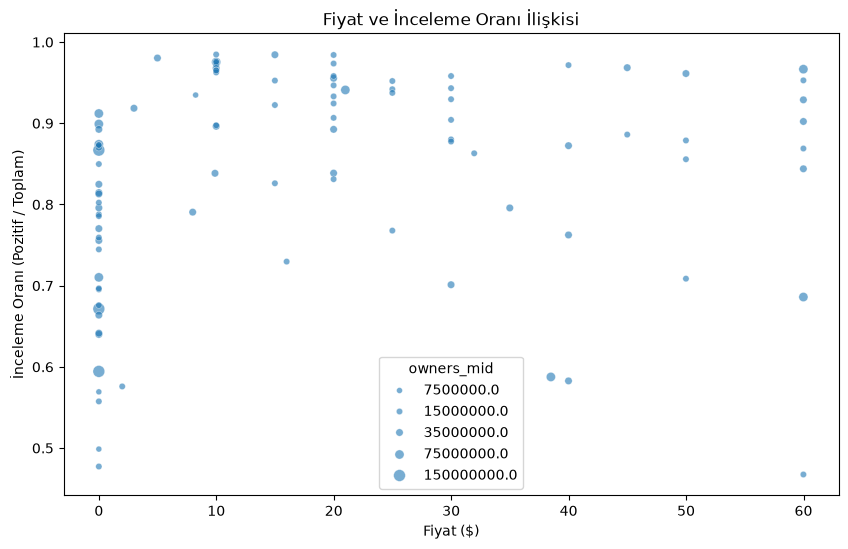

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

df['review_ratio'] = df['positive'] / (df['positive'] + df['negative'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='review_ratio', size='owners_mid', alpha=0.6)
plt.title('Fiyat ve İnceleme Oranı İlişkisi')
plt.xlabel('Fiyat ($)')
plt.ylabel('İnceleme Oranı (Pozitif / Toplam)')
plt.show()

           


In [21]:
korelasyon = df['price'].corr(df['review_ratio'])
print(korelasyon)

0.17631919335147345


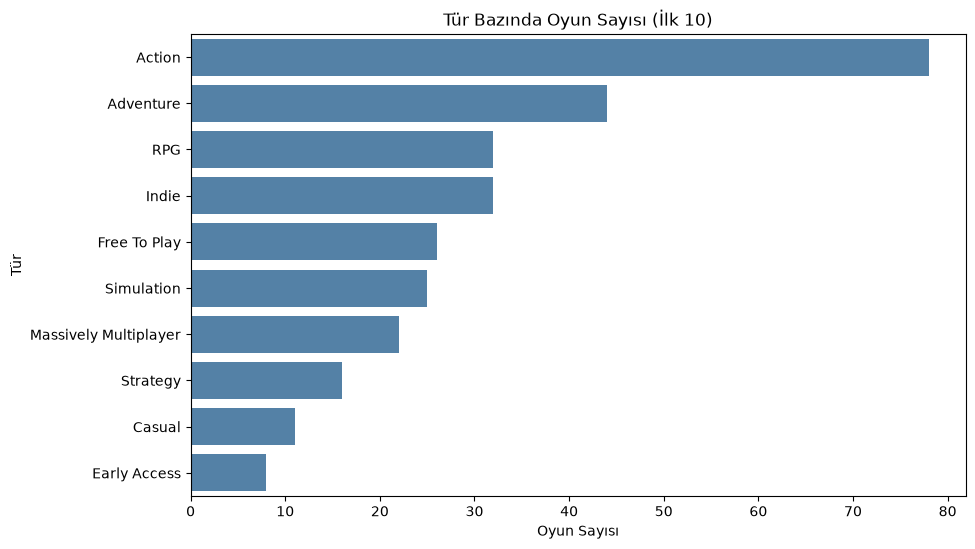

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_real_stats, x='oyun_sayisi', y='genre_list', color='steelblue')
plt.title('Tür Bazında Oyun Sayısı (İlk 10)')
plt.xlabel('Oyun Sayısı')
plt.ylabel('Tür')
plt.show()

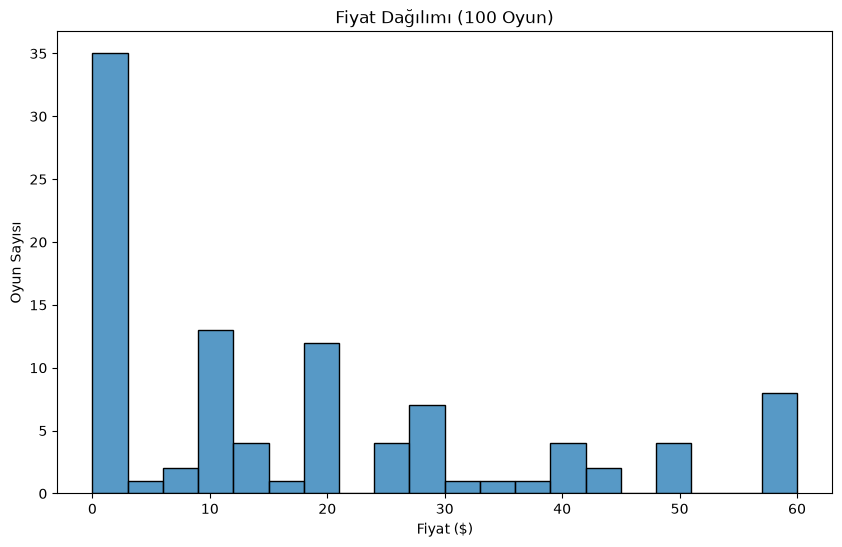

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='price', bins=20)
plt.title('Fiyat Dağılımı (100 Oyun)')
plt.xlabel('Fiyat ($)')
plt.ylabel('Oyun Sayısı')
plt.show()

## Sonuç ve Bulgular

Bu projede SteamSpy API'sinden en popüler 100 oyunun verisini çektim, pandas ile temizledim, 
SQLite'a yazıp SQL sorgularıyla analiz ettim, seaborn ile görselleştirdim.

**Öne çıkan bulgular:**
- Fiyat ile inceleme oranı arasında zayıf bir pozitif ilişki var (korelasyon: 0.18) — 
  fiyat, oyun kalitesinin güçlü bir göstergesi değil.
- "Action" türü, en yaygın tür kombinasyonu — diğer türlerden neredeyse iki kat önde.
- İncelenen oyunların üçte biri ücretsiz (free-to-play), kalan çoğunluk 10-20$ 
  aralığında yoğunlaşıyor.
  